# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd

df = pd.read_csv("delivery_dataset.csv")

print("Размер датасета:", df.shape)
display(df)


Размер датасета: (500, 8)


,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

300 первых заказов - train, 100 следующих — validation, 100 последних - test. Целевой признак — время доставки, остальные числовые характеристики используются как признаки.

In [2]:
features = [
    "Расстояние до клиента (в км)",
    "Количество позиций в чеке (в шт.)",
    "Балл пробок на дорогах (в баллах)",
    "Погода (в градусах Цельсия)",
    "Этаж доставки (в этажах)"
]
target = "Время доставки (в минутах)"

X = df[features]
y = df[target]

X_train, y_train = X.iloc[:300], y.iloc[:300]
X_val, y_val = X.iloc[300:400], y.iloc[300:400]
X_test, y_test = X.iloc[400:500], y.iloc[400:500]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape)


Train: (300, 5) (300,)
Validation: (100, 5) (100,)
Test: (100, 5)


#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

Для того, чтобы честно проверить, как модель работает на новых данных. На **тренировочной** модель учтся. На **валидационной** подбирают настройки модели и сравнивают варианты. Тестовая выборка нужна только в конце, чтобы оценить итоговое качество модели на данных, которых она раньше не видела.

### Шаг 3. Установка sklearn

Библиотека `scikit-learn` нужна для готовой реализации линейной регрессии через `Ridge`.

В следующей ячейке используется `alpha=0.0`, поэтому регуляризация Ridge отключена. Решатель `sparse_cg` реализует метод сопряжённых градиентов.

In [3]:
# scikit-learn уже установлен в среде выполнения.

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

**Идея:** `Ridge` с `alpha=0` используется здесь как удобный интерфейс к решателю `sparse_cg`. Модель обучается только на `train`; validation пока используется для контроля качества.

In [4]:
import numpy as np
from sklearn.linear_model import Ridge

# alpha=0 отключает регуляризацию Ridge и оставляет линейную регрессию.
# sparse_cg — решатель методом сопряжённых градиентов.
model = Ridge(alpha=0.0, solver="sparse_cg")
model.fit(X_train, y_train)

print("Свободный член (intercept):", model.intercept_)
print("Коэффициенты:")
display(pd.Series(model.coef_, index=features, name="weight"))

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

def regression_metrics(y_true, y_pred):
    error = np.asarray(y_true) - np.asarray(y_pred)
    sse = np.sum(error ** 2)
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    return sse, mse, rmse

print("Train SSE/MSE/RMSE:", regression_metrics(y_train, y_train_pred))
print("Val   SSE/MSE/RMSE:", regression_metrics(y_val, y_val_pred))


Свободный член (intercept): -2.9673282180037432
Коэффициенты:


Расстояние до клиента (в км)         4.396127
Количество позиций в чеке (в шт.)    0.835327
Балл пробок на дорогах (в баллах)    2.153894
Погода (в градусах Цельсия)         -0.047348
Этаж доставки (в этажах)             0.343231
Name: weight, dtype: float64

Train SSE/MSE/RMSE: (np.float64(5529.134405829646), np.float64(18.430448019432156), np.float64(4.29306976642963))
Val   SSE/MSE/RMSE: (np.float64(2078.505244796125), np.float64(20.785052447961252), np.float64(4.55906267208088))


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

**Что делаем вручную:** `Ridge` не предоставляет траекторию SSE/MSE/RMSE по каждой итерации, поэтому повторяем алгоритм сопряжённых градиентов самостоятельно. Для линейной регрессии составляем `A = XᵀX` и `b = Xᵀy`, затем итеративно обновляем веса `w`, невязку `r` и направление `p`. На каждом шаге сохраняем ошибки для train и validation.

Число итераций: 8
Финальная норма невязки: 2.5256006991754865e-09
Ручные веса:


intercept                           -2.967328
Расстояние до клиента (в км)         4.396127
Количество позиций в чеке (в шт.)    0.835327
Балл пробок на дорогах (в баллах)    2.153894
Погода (в градусах Цельсия)         -0.047348
Этаж доставки (в этажах)             0.343231
Name: weight, dtype: float64


Максимальное отличие весов от sklearn: 2.3003821070233244e-13


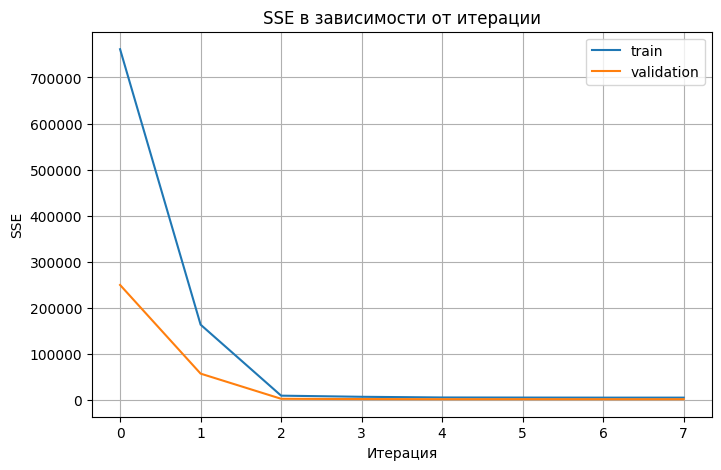

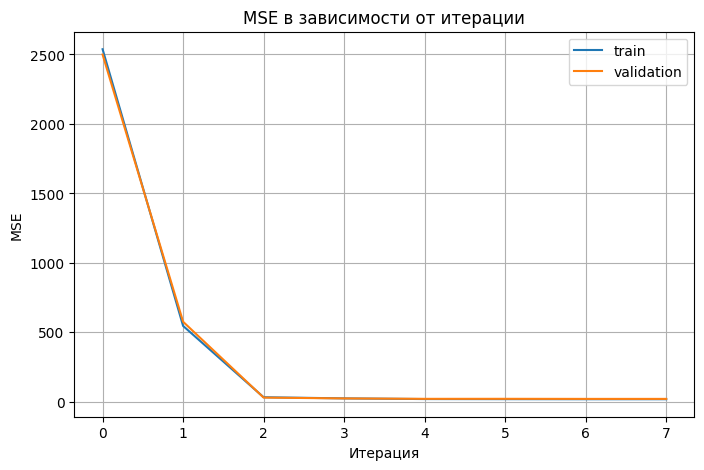

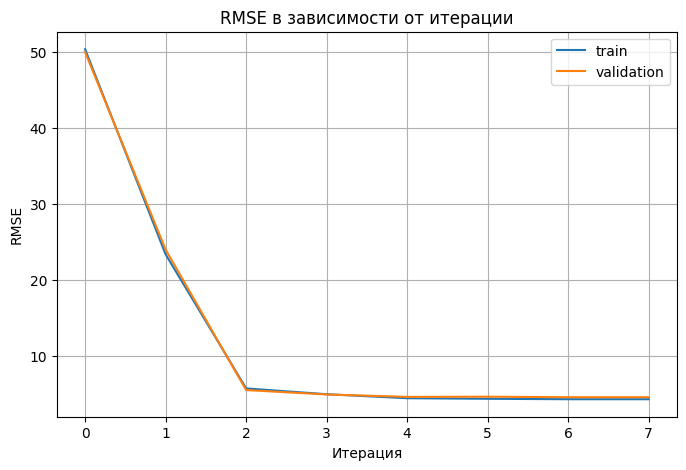

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Добавляем столбец единиц, чтобы вручную учитывать свободный член w0.
Xtr = np.column_stack([np.ones(len(X_train)), X_train.to_numpy(dtype=float)])
Xv = np.column_stack([np.ones(len(X_val)), X_val.to_numpy(dtype=float)])
ytr = y_train.to_numpy(dtype=float)
yv = y_val.to_numpy(dtype=float)

# Для линейной регрессии решаем систему A w = b,
# где A = X^T X, b = X^T y.
A = Xtr.T @ Xtr
b = Xtr.T @ ytr

epsilon = 1e-8
max_iterations = 100

w = np.zeros(Xtr.shape[1])
r = b - A @ w
p = r.copy()

iterations = []
train_sse_history, train_mse_history, train_rmse_history = [], [], []
val_sse_history, val_mse_history, val_rmse_history = [], [], []

for k in range(max_iterations):
    # Ошибки на текущих весах
    train_pred = Xtr @ w
    val_pred = Xv @ w

    train_sse, train_mse, train_rmse = regression_metrics(ytr, train_pred)
    val_sse, val_mse, val_rmse = regression_metrics(yv, val_pred)

    iterations.append(k)
    train_sse_history.append(train_sse)
    train_mse_history.append(train_mse)
    train_rmse_history.append(train_rmse)
    val_sse_history.append(val_sse)
    val_mse_history.append(val_mse)
    val_rmse_history.append(val_rmse)

    # Критерий остановки из алгоритма лекции
    if np.linalg.norm(r) < epsilon:
        break

    Ap = A @ p
    alpha_k = (r @ r) / (p @ Ap)

    w_new = w + alpha_k * p
    r_new = r - alpha_k * Ap
    beta_k = (r_new @ r_new) / (r @ r)
    p_new = r_new + beta_k * p

    w, r, p = w_new, r_new, p_new

print("Число итераций:", len(iterations))
print("Финальная норма невязки:", np.linalg.norm(r))
print("Ручные веса:")
display(pd.Series(w, index=["intercept"] + features, name="weight"))

print("\nМаксимальное отличие весов от sklearn:",
      np.max(np.abs(w - np.r_[model.intercept_, model.coef_])))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, train_sse_history, label="train")
ax.plot(iterations, val_sse_history, label="validation")
ax.set_xlabel("Итерация")
ax.set_ylabel("SSE")
ax.set_title("SSE в зависимости от итерации")
ax.legend()
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, train_mse_history, label="train")
ax.plot(iterations, val_mse_history, label="validation")
ax.set_xlabel("Итерация")
ax.set_ylabel("MSE")
ax.set_title("MSE в зависимости от итерации")
ax.legend()
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, train_rmse_history, label="train")
ax.plot(iterations, val_rmse_history, label="validation")
ax.set_xlabel("Итерация")
ax.set_ylabel("RMSE")
ax.set_title("RMSE в зависимости от итерации")
ax.legend()
ax.grid(True)
plt.show()


#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

Они показывают как меняется ошибки модели на обучающей и валидационноой выборках. По ним видно, недообучается модель, переобучается или обучается нормально. 

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

При недообучении train и validation ошибки обе высокие и почти идут рядом - модель плохо учится. Когда модель нормально обученная, то обе ошибки снижаются и стабилизируется на низком уровне, в итоге модель хорошо обобщает. Когда модель переобученная, то train ошибка продолжает снижаться, а validate после снижения начинает расти, модель запоминает обучающие данные.

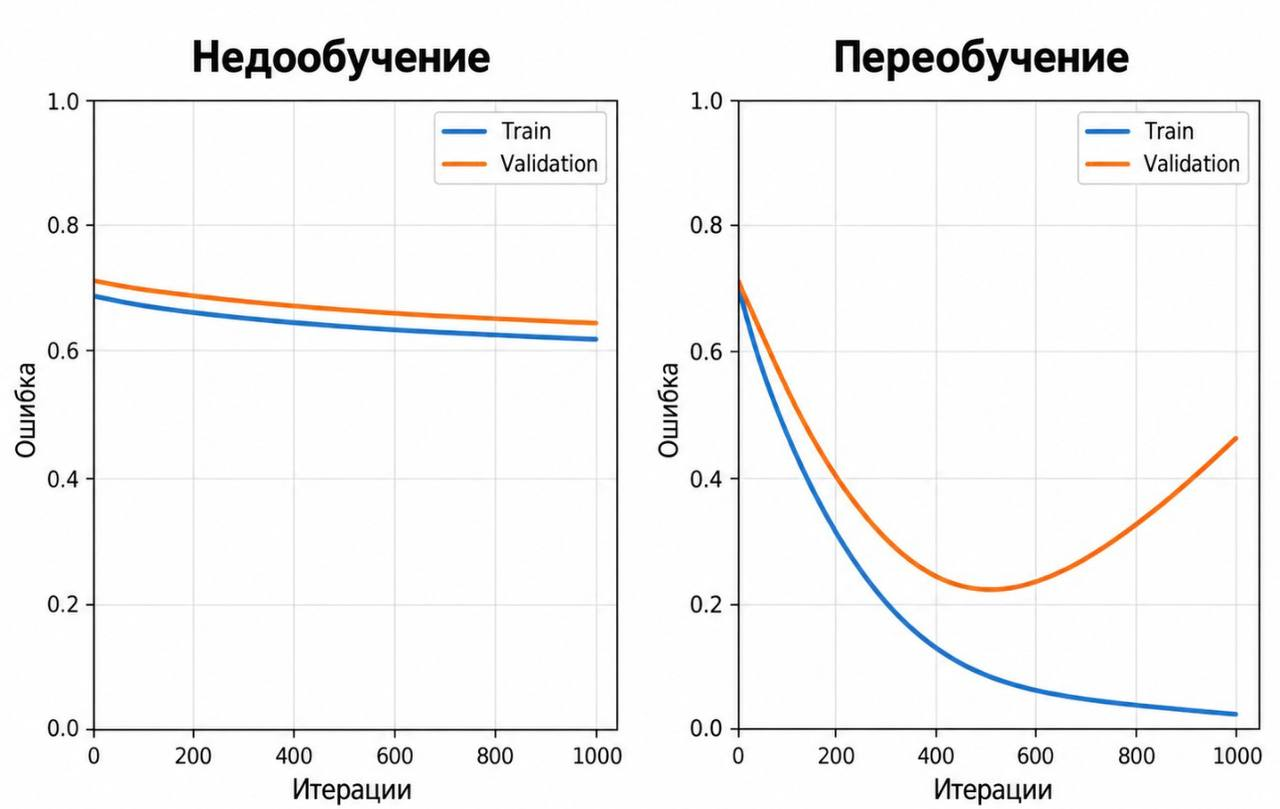

### Вывод по шагу 5

По графикам ошибки на `train` и `validation` уменьшаются и затем выходят на практически стабильные значения. Validation-ошибка не начинает устойчиво расти при дальнейшем уменьшении train-ошибки. Поэтому по критериям задания модель **обучена**, а выраженного переобучения не наблюдается.

Для этого датасета финальные значения находятся примерно на уровнях:
- train RMSE ≈ 4.29 мин;
- validation RMSE ≈ 4.56 мин.

Разница небольшая, поэтому качество на новых объектах сопоставимо с качеством на обучающих данных.

### Шаг 6. Применение модели на тестовой выборке

После обучения модель не переобучаем на test. Для каждой из последних 100 доставок получаем прогноз времени доставки и сравниваем его с настоящим значением.

В итоговой таблице:
- `ID заказа` — идентификатор заказа;
- `Предсказанное время` — прогноз модели;
- `Настоящее время` — фактическое время доставки;
- `Разница (предсказание - факт)` — signed error;
- `Абсолютная ошибка` — модуль разницы.


test должен оставаться независимой финальной проверкой. Если использовать его для подбора модели, итоговая оценка станет менее объективной.

In [6]:
y_predict = model.predict(X_test)

test_predictions = pd.DataFrame({
    "ID заказа": df.iloc[400:500]["Шифр заказа (ID)"].to_numpy(),
    "Предсказанное время (мин)": y_predict,
    "Настоящее время (мин)": y_test.to_numpy(),
})

test_predictions["Разница (предсказание - факт)"] = (
    test_predictions["Предсказанное время (мин)"]
    - test_predictions["Настоящее время (мин)"]
)
test_predictions["Абсолютная ошибка (мин)"] = (
    test_predictions["Разница (предсказание - факт)"].abs()
)

display(test_predictions.round(2))

test_predictions.to_csv("delivery_test_predictions.csv", index=False)
print("Таблица сохранена в delivery_test_predictions.csv")


,ID заказа,Предсказанное время (мин),Настоящее время (мин),Разница (предсказание - факт),Абсолютная ошибка (мин)
0,ORD-202608401,33.07,33.9,-0.83,0.83
1,ORD-202608402,33.13,33.1,0.03,0.03
2,ORD-202608403,20.85,16.3,4.55,4.55
3,ORD-202608404,34.39,34.7,-0.31,0.31
4,ORD-202608405,17.56,13.3,4.26,4.26
...,...,...,...,...,...
95,ORD-202608496,30.26,28.9,1.36,1.36
96,ORD-202608497,54.53,48.0,6.53,6.53
97,ORD-202608498,28.61,27.0,1.61,1.61
98,ORD-202608499,41.58,40.4,1.18,1.18


Таблица сохранена в delivery_test_predictions.csv


### Шаг 7. RMSE на тестовой выборке

Финальное качество оцениваем на test, который не использовался для обучения модели.



In [7]:
_, test_mse, test_rmse = regression_metrics(y_test, y_predict)

print(f"Test MSE:  {test_mse:.6f}")
print(f"Test RMSE: {test_rmse:.6f} мин")

print(
    "\nВывод: модель обучена удовлетворительно. "
    "Ошибка на train, validation и test близка по порядку величины, "
    "поэтому выраженного переобучения по этим выборкам не наблюдается."
)


Test MSE:  23.339835
Test RMSE: 4.831132 мин

Вывод: модель обучена удовлетворительно. Ошибка на train, validation и test близка по порядку величины, поэтому выраженного переобучения по этим выборкам не наблюдается.


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

RMSE показывает среднюю величину ошибки модели в минутах. В нашем случае модель ошибается примерно на 4.83 минуты при предсказании времени доставки.